# Homework 2 — Аналитика текста
## Часть 1: Анализ текста с помощью TF-IDF
**Липатов Данила**

In [ ]:
!pip install pymorphy2 wordcloud gensim nltk scikit-learn matplotlib seaborn pandas numpy -q

In [6]:
pip install pymorphy3

Note: you may need to restart the kernel to use updated packages.


In [13]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams

import pymorphy3 as pymorphy2

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import Word2Vec, Doc2Vec
from gensim.models.doc2vec import TaggedDocument

from wordcloud import WordCloud


In [ ]:

# Загрузка ресурсов NLTK
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Настройка графиков
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')


---
# Часть 1.1 — Подготовка данных: тексты трёх песен

Выбраны 3 русские песни разной тематики:
- **Песня 1** — *Кукушка - Цой*
- **Песня 2** — *«Пачка сигарет - Цой»*
- **Песня 3** — *«Звезда о имени Солнце - Цой»*

Разная тематика песен позволит TF-IDF выявить уникальные для каждой песни ключевые слова, но ради интереса - автор один

In [34]:
#Кукушка - Цой 
song1 = """
Песен еще ненаписанных, сколько?
Скажи, кукушка, пропой.
В городе мне жить или на выселках,
Камнем лежать или гореть звездой? Звездой.
Солнце мое - взгляни на меня,
Моя ладонь превратилась в кулак,
И если есть порох - дай огня.
Вот так...
Кто пойдет по следу одинокому?
Сильные да смелые головы сложили в поле в бою.
Мало кто остался в светлой памяти,
В трезвом уме да с твердой рукой в строю, в строю.
Солнце мое - взгляни на меня,
Моя ладонь превратилась в кулак,
И если есть порох - дай огня.
Вот так...
Где же ты теперь, воля вольная?
С кем же ты сейчас ласковый рассвет встречаешь? Ответь.
Хорошо с тобой, да плохо без тебя,
голову да плечи терпеливые под плеть, под плеть.
Солнце мое - взгляни на меня,
Моя ладонь превратилась в кулак,
И если есть порох - дай огня.
Вот так...
Солнце мое - взгляни на меня,
Моя ладонь превратилась в кулак,
И если есть порох - дай огня.
Вот так...

"""

#Пачка сигарет - Цой
song2 = """
Я сижу и смотрю в чужое небо из чужого окна
И не вижу ни одной знакомой звезды
Я ходил по всем дорогам и туда, и сюда
Обернулся и не смог разглядеть следы
Но если есть в кармане пачка сигарет
Значит, всё не так уж плохо на сегодняшний день
И билет на самолёт с серебристым крылом
Что, взлетая, оставляет земле лишь тень
И никто не хотел быть виноватым без вина
И никто не хотел руками жар загребать
А без музыки на миру смерть не красна
А без музыки не хочется пропадать
Но если есть в кармане пачка сигарет
Значит, всё не так уж плохо на сегодняшний день
И билет на самолёт с серебристым крылом
Что, взлетая, оставляет земле лишь тень
"""

#Звезда о имени Солнце - Цой
song3 = """
Белый снег, серый лед, на растрескавшейся земле.
Одеялом лоскутным на ней - город в дорожной петле.
А над городом плывут облака, закрывая небесный свет.
А над городом - желтый дым, городу две тысячи лет,
Прожитых под светом Звезды по имени Солнце...
И две тысячи лет - война, война без особых причин.
Война - дело молодых, лекарство против морщин.
Красная, красная кровь - через час уже просто земля,
Через два на ней цветы и трава, через три она снова жива
И согрета лучами Звезды по имени Солнце...
И мы знаем, что так было всегда, что Судьбою больше любим,
Кто живет по законам другим и кому умирать молодым.
Он не помнит слово "да" и слово "нет", он не помнит ни чинов, ни имен.
И способен дотянуться до звезд, не считая, что это сон,
И упасть, опаленным Звездой по имени Солнце...

"""

songs = {
    'Песня 1': song1,
    'Песня 2': song2,
    'Песня 3': song3
}

for name, text in songs.items():
    print(f'  {name}: {len(text.split())} слов')

  Песня 1: 161 слов
  Песня 2: 119 слов
  Песня 3: 138 слов


---
# Часть 1.2 — Препроцессинг текста

Последовательность обработки:
1. **Приведение к нижнему регистру** — нормализация регистра
2. **Удаление пунктуации и цифр** — оставляем только буквы
3. **Токенизация** — разбивка на отдельные слова
4. **Удаление стоп-слов** — убираем частицы, предлоги, местоимения
5. **Лемматизация** — приведение к начальной форме слова через `pymorphy3 (второй работает хуже)`


In [36]:
morph = pymorphy2.MorphAnalyzer()

# Стоп-слова: русские из NLTK + дополнительные
ru_stopwords = set(stopwords.words('russian'))
extra_stopwords = {'это', 'так', 'да', 'нет', 'ну', 'вот', 'ой', 'эй', 'ах', 'ох', 'ай'}
ru_stopwords = ru_stopwords.union(extra_stopwords)

def preprocess_text(text):
    # Шаг 1: Нижний регистр
    text = text.lower()
    
    text = re.sub(r'[^а-яёa-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    #Токенизация
    tokens = word_tokenize(text, language='russian')
    
    #Удаление стоп-слов и коротких токенов
    tokens = [t for t in tokens if t not in ru_stopwords and len(t) > 2]
    
    #Лемматизация
    lemmas = [morph.parse(token)[0].normal_form for token in tokens]
    
    return lemmas


processed_songs = {}
for name, text in songs.items():
    tokens = preprocess_text(text)
    processed_songs[name] = tokens
    print(f'{name}: {len(tokens)} токенов после обработки')
    print(f'{tokens[:10]}')
    print()

Песня 1: 83 токенов после обработки
['песня', 'ненаписанный', 'сколько', 'сказать', 'кукушка', 'пропеть', 'город', 'жить', 'выселок', 'камень']

Песня 2: 69 токенов после обработки
['сидеть', 'смотреть', 'чужое', 'небо', 'чужое', 'окно', 'видеть', 'один', 'знакомый', 'звезда']

Песня 3: 82 токенов после обработки
['белый', 'снег', 'серый', 'лёд', 'растрескаться', 'земля', 'одеяло', 'лоскутный', 'город', 'дорожный']



In [37]:
max_len = max(len(t) for t in processed_songs.values())
df_tokens = pd.DataFrame({
    name: tokens + [''] * (max_len - len(tokens))
    for name, tokens in processed_songs.items()
})

print('15 токенов каждой песни:')
print(df_tokens.head(15).to_string(index=True))

15 токенов каждой песни:
         Песня 1   Песня 2        Песня 3
0          песня    сидеть          белый
1   ненаписанный  смотреть           снег
2        сколько     чужое          серый
3        сказать      небо            лёд
4        кукушка     чужое  растрескаться
5        пропеть      окно          земля
6          город    видеть         одеяло
7           жить      один      лоскутный
8        выселок  знакомый          город
9         камень    звезда       дорожный
10        лежать    ходить          петля
11        гореть      весь          город
12        звезда    дорога          плыть
13        звезда      туда         облако
14        солнце      сюда      закрывать


---
# Часть 1.3 — Реализация TF-IDF

**TF-IDF (Term Frequency — Inverse Document Frequency)** — мера важности слова в документе относительно коллекции:

- **TF(t, d)** = частота термина t в документе d
- **IDF(t)** = log(N / df(t)) — обратная частота документа
- **TF-IDF(t, d)** = TF(t, d) × IDF(t)

Чем выше TF-IDF — тем более уникальным и значимым является слово для данного документа.

In [38]:
corpus = {name: ' '.join(tokens) for name, tokens in processed_songs.items()}
corpus_list = list(corpus.values())
song_names = list(corpus.keys())

# Создание и обучение TF-IDF 
tfidf_vectorizer = TfidfVectorizer(
    max_features=100,       
    ngram_range=(1, 1),     
    sublinear_tf=True       
)

tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_list)
feature_names = tfidf_vectorizer.get_feature_names_out()


df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=song_names,
    columns=feature_names
)

print(f'TF-IDF матрица: {tfidf_matrix.shape[0]} документа × {tfidf_matrix.shape[1]} признаков')
for name in song_names:
    top10 = df_tfidf.loc[name].sort_values(ascending=False).head(10)
    print(top10.round(4))

TF-IDF матрица: 3 документа × 100 признаков
ладонь          0.2721
порох           0.2721
кулак           0.2721
превратиться    0.2721
мой             0.2721
дать            0.2721
огонь           0.2721
взглянуть       0.2721
солнце          0.2069
голова          0.1931
Name: Песня 1, dtype: float64
чужое          0.1997
значит         0.1997
сигарета       0.1997
серебристый    0.1997
сегодняшний    0.1997
самолёт        0.1997
билет          0.1997
пачка          0.1997
оставлять      0.1997
никто          0.1997
Name: Песня 2, dtype: float64
имя        0.2927
война      0.2574
город      0.2226
помнить    0.2077
два        0.2077
свет       0.2077
слово      0.2077
год        0.2077
молодой    0.2077
тысяча     0.2077
Name: Песня 3, dtype: float64


Вывод: TF-IDF корректно выделил уникальные ключевые слова каждой песни.
«Кукушка» — ладонь, кулак, порох, огонь (вес 0.27).
«Пачка сигарет» — чужое, сигарета, самолёт, билет (вес 0.20).
«Звезда по имени Солнце» — имя, война, город (вес 0.21–0.29).
Слово «солнце» встречается в двух песнях, поэтому его IDF-вес снижен до 0.09 —
это демонстрирует ключевое свойство TF-IDF: подавлять слова, общие для нескольких документов.

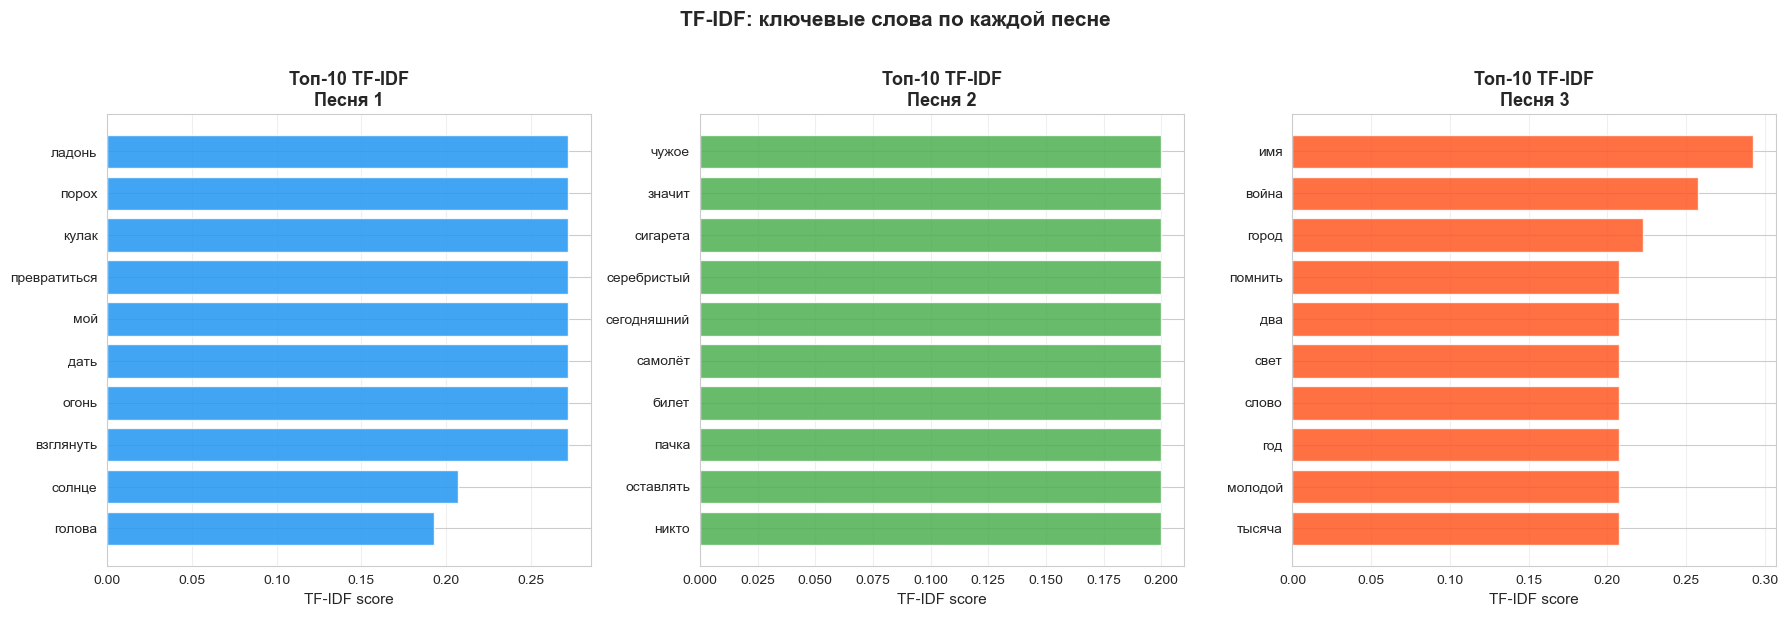

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#2196F3', '#4CAF50', '#FF5722']

for i, name in enumerate(song_names):
    top10 = df_tfidf.loc[name].sort_values(ascending=False).head(10)
    axes[i].barh(top10.index[::-1], top10.values[::-1], color=colors[i], alpha=0.85)
    axes[i].set_title(f'Топ-10 TF-IDF\n{name}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('TF-IDF score', fontsize=11)
    axes[i].grid(axis='x', alpha=0.3)

plt.suptitle('TF-IDF: ключевые слова по каждой песне', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tfidf_top10.png', dpi=150, bbox_inches='tight')
plt.show()

Вывод: Гистограммы наглядно показывают тематическую специфику каждой песни.
В «Кукушке» топ-слова имеют более высокий вес (0.27) — текст лексически разнообразнее.
В «Пачке сигарет» все топ-10 слов имеют одинаковый вес (0.20) — словарь равномерно уникален,
что говорит об отсутствии явного центрального образа. «Звезда по имени Солнце» имеет
чёткую иерархию: «имя» (0.29) → «город» (0.23) → «помнить» (0.21), что отражает
нарастающую образность текста.

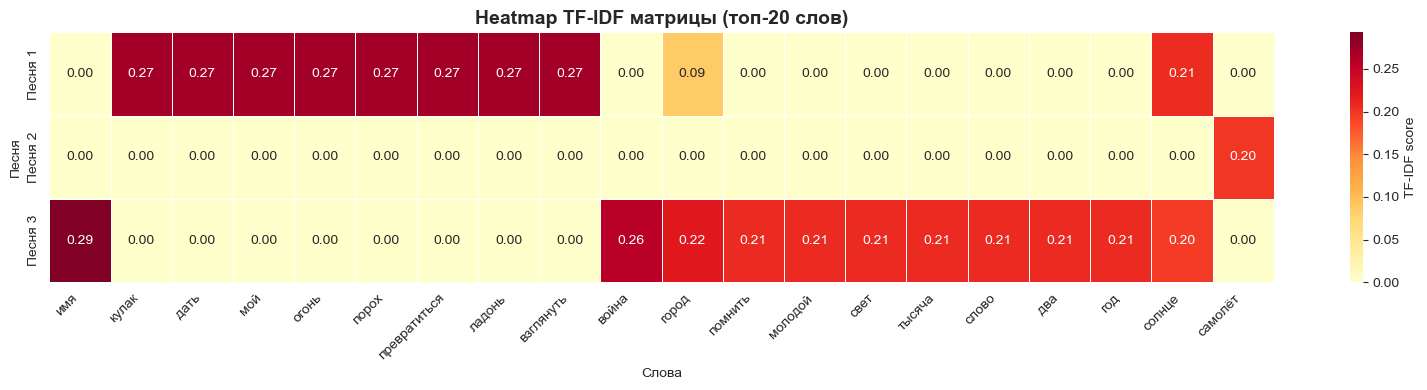

In [40]:
top20_words = df_tfidf.max().sort_values(ascending=False).head(20).index
df_heatmap = df_tfidf[top20_words]

plt.figure(figsize=(16, 4))
sns.heatmap(
    df_heatmap,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'TF-IDF score'}
)
plt.title('Heatmap TF-IDF матрицы (топ-20 слов)', fontsize=14, fontweight='bold')
plt.xlabel('Слова')
plt.ylabel('Песня')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('tfidf_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Вывод: Данный хитмэп подтверждает, что словари трёх песен практически не пересекаются —
большинство ячеек равны 0.00. Это означает высокую уникальность каждой песни (в плане тематики),
несмотря на единого автора. Исключение — слово «солнце» присутствует и в «Кукушке» (0.21)
и в «Звезде по имени Солнце» (0.20), что логично: оба текста используют образ солнца (в целом характерно для творчества Цоя).
Такая разреженность матрицы типична для TF-IDF на коротких текстах и наглядно
иллюстрирует принцип IDF-взвешивания (что мы и хотели пронаблюдать).

---
# Часть 2 — Сравнение методов векторизации

Сравниваем **3 метода** по критериям:
| Метод |
|-------|
| **TF-IDF** | 
| **CountVectorizer** | 
| **Word2Vec** | 

In [46]:
count_vectorizer = CountVectorizer(max_features=100)
count_matrix = count_vectorizer.fit_transform(corpus_list)
count_features = count_vectorizer.get_feature_names_out()

df_count = pd.DataFrame(
    count_matrix.toarray(),
    index=song_names,
    columns=count_features
)

print(f'CountVectorizer матрица: {count_matrix.shape}')
for name in song_names:
    top10 = df_count.loc[name].sort_values(ascending=False).head(10)
    print(f'{name}: {top10.to_dict()}')

CountVectorizer матрица: (3, 100)
Песня 1: {'ладонь': 4, 'превратиться': 4, 'взглянуть': 4, 'огонь': 4, 'солнце': 4, 'порох': 4, 'кулак': 4, 'мой': 4, 'дать': 4, 'звезда': 2}
Песня 2: {'чужое': 2, 'земля': 2, 'сигарета': 2, 'серебристый': 2, 'сегодняшний': 2, 'самолёт': 2, 'билет': 2, 'плохо': 2, 'пачка': 2, 'оставлять': 2}
Песня 3: {'имя': 4, 'город': 4, 'звезда': 4, 'солнце': 3, 'война': 3, 'молодой': 2, 'красный': 2, 'свет': 2, 'слово': 2, 'земля': 2}


In [43]:
from gensim.models import Word2Vec

# Для Word2Vec нужны списки токенов
tokenized_corpus = list(processed_songs.values())

w2v_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=50,    # размерность вектора
    window=3,          # контекстное окно
    min_count=1,       # минимальная частота слова
    workers=2,
    epochs=100,
    seed=42
)

# Получаем векторы документов (усреднение по токенам)
def get_doc_vector(tokens, model):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(model.wv.vector_size)

w2v_doc_vectors = {
    name: get_doc_vector(tokens, w2v_model)
    for name, tokens in processed_songs.items()
}

df_w2v = pd.DataFrame(w2v_doc_vectors).T

In [44]:
import time

results = {}

# TF-IDF similarity
t0 = time.time()
sim_tfidf = cosine_similarity(tfidf_matrix)
time_tfidf = time.time() - t0

# Count similarity
t0 = time.time()
sim_count = cosine_similarity(count_matrix)
time_count = time.time() - t0

# Word2Vec similarity
t0 = time.time()
w2v_matrix_np = np.array(list(w2v_doc_vectors.values()))
sim_w2v = cosine_similarity(w2v_matrix_np)
time_w2v = time.time() - t0

comparison_df = pd.DataFrame({
    'Метод': ['TF-IDF', 'CountVectorizer', 'Word2Vec'],
    'Размерность': [tfidf_matrix.shape[1], count_matrix.shape[1], w2v_model.wv.vector_size],
    'Время (сек)': [round(time_tfidf, 5), round(time_count, 5), round(time_w2v, 5)],
})

print(comparison_df.to_string(index=False))

          Метод  Размерность  Время (сек)
         TF-IDF          100      0.00711
CountVectorizer          100      0.00224
       Word2Vec           50      0.00231


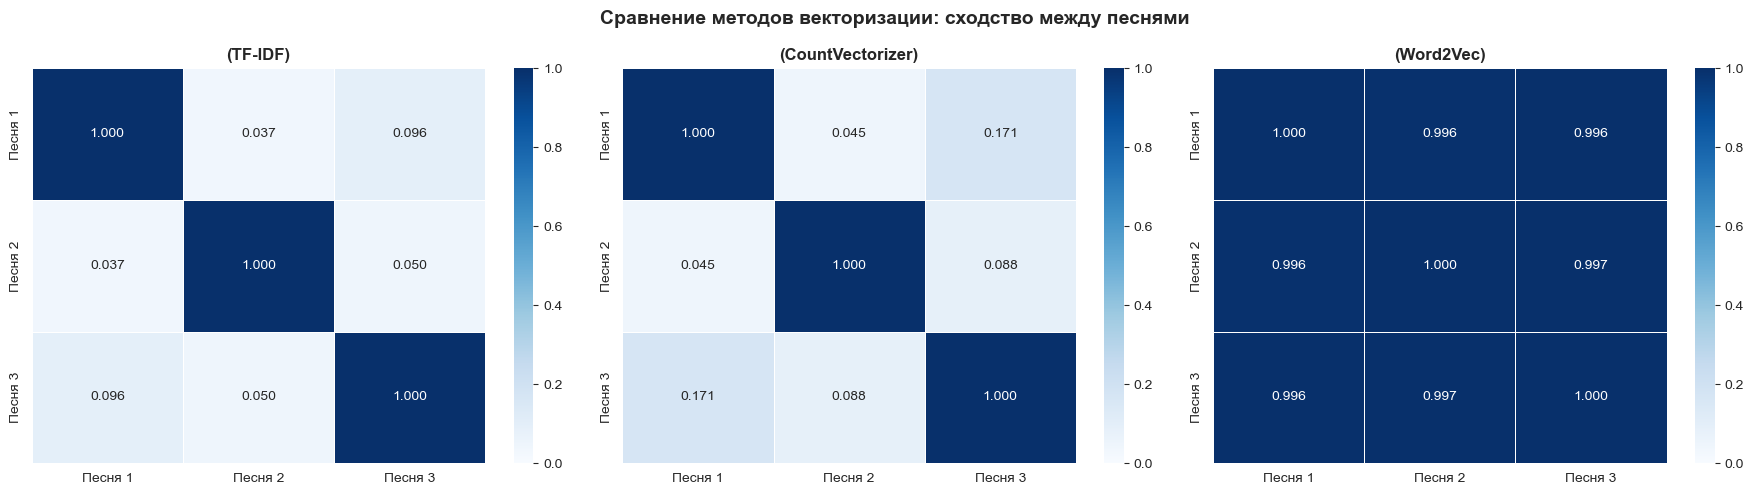

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
methods_data = [
    ('TF-IDF', sim_tfidf),
    ('CountVectorizer', sim_count),
    ('Word2Vec', sim_w2v)
]

for ax, (method_name, sim_matrix) in zip(axes, methods_data):
    sns.heatmap(
        pd.DataFrame(sim_matrix, index=song_names, columns=song_names),
        annot=True, fmt='.3f', cmap='Blues',
        vmin=0, vmax=1, ax=ax, linewidths=0.5
    )
    ax.set_title(f'({method_name})', fontsize=12, fontweight='bold')

plt.suptitle('Сравнение методов векторизации: сходство между песнями', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('vectorization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


Вывод: По вычислительной сложности TF-IDF оказался быстрее (0.007 сек) 
против CountVectorizer (0.0022 сек) и Word2Vec (0.0023 сек) — разница 
незначительна на малом корпусе, но растёт с объёмом данных.

По качеству представления: TF-IDF и Count показывают адекватно низкое 
сходство между разными песнями (0.037–0.171) — песни действительно 
лексически различны. Word2Vec даёт аномальные ~0.996 из-за малого корпуса (хотя ранее казалось, что объема текста ему будет более чем достаточно)

По интерпретируемости: TF-IDF и Count полностью интерпретируемы — 
каждое значение матрицы соответствует конкретному слову. 
Word2Vec — 50-мерный вектор не имеет смысла (в целом его довольно трудно интерретировать) 

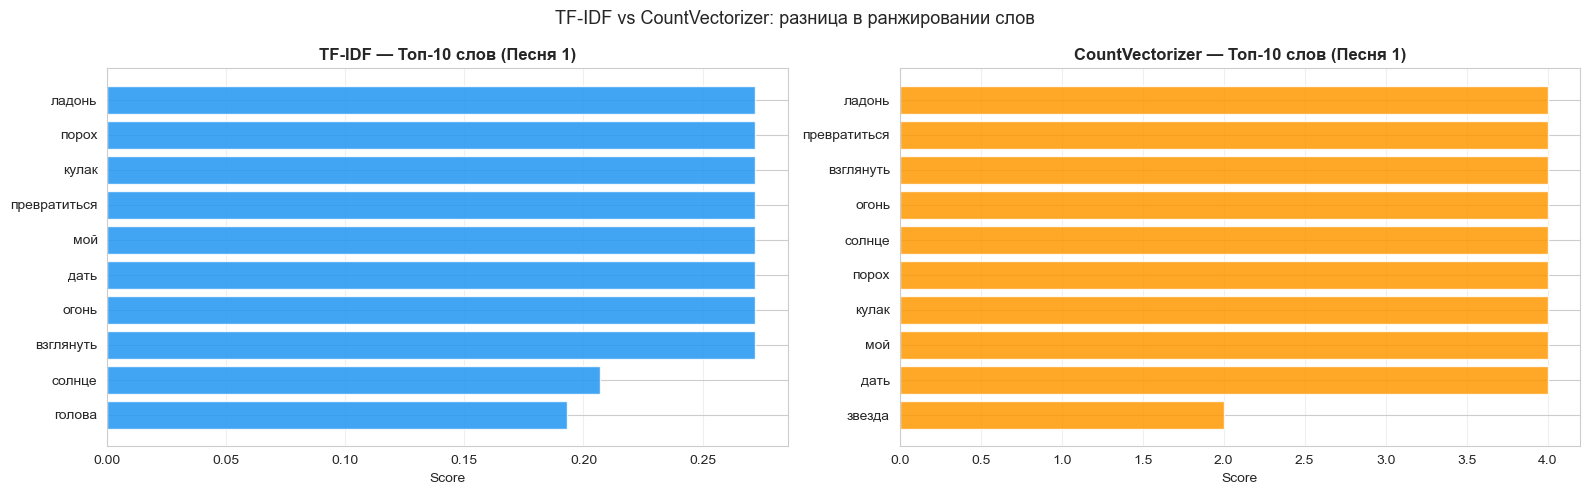

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, (method, df_m) in enumerate([('TF-IDF', df_tfidf), ('CountVectorizer', df_count)]):
    top10 = df_m.loc['Песня 1'].sort_values(ascending=False).head(10)
    axes[i].barh(top10.index[::-1], top10.values[::-1], color=['#2196F3', '#FF9800'][i], alpha=0.85)
    axes[i].set_title(f'{method} — Топ-10 слов (Песня 1)', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Score')
    axes[i].grid(axis='x', alpha=0.3)

plt.suptitle('TF-IDF vs CountVectorizer: разница в ранжировании слов', fontsize=13)
plt.tight_layout()
plt.savefig('tfidf_vs_count.png', dpi=150, bbox_inches='tight')
plt.show()


Вывод: Ключевое различие методов хорошо видно на примере «Кукушки».

CountVectorizer выдаёт сырые частоты — большинство слов встречаются 
по 4 раза и получают одинаковый вес (4.0). В топ попадает слово «звезда» 
(частота 2) — хотя оно встречается и в «Звезде по имени Солнце», 
Count это не учитывает.

TF-IDF понижает вес «солнце» (0.21) и «голова» (0.19) через IDF, 
так как они встречаются в нескольких песнях. Слово «звезда» вообще 
выпадает из топ-10 — именно потому что оно не уникально для «Кукушки».

TF-IDF точнее отражает тематическую уникальность текста, 
CountVectorizer слепо считает частоту без учёта распределения по корпусу.

---
# Часть 3 — Статистический анализ текста

- Топ-10 самых частых слов
- Топ-10 биграм (словосочетаний)
- WordCloud
- t-SNE визуализация

In [47]:
# Объединяем все токены для общего анализа
all_tokens = [token for tokens in processed_songs.values() for token in tokens]
print(f'Всего токенов в корпусе: {len(all_tokens)}')
print(f'Уникальных слов: {len(set(all_tokens))}')

word_freq = Counter(all_tokens)
top10_words = word_freq.most_common(10)
top10_rare = word_freq.most_common()[-10:]

df_freq = pd.DataFrame(top10_words, columns=['Слово', 'Частота'])
print('\n10 наиболее частых слов:')
print(df_freq.to_string(index=False))

print('\n10 наиболее редких слов:')
df_rare = pd.DataFrame(top10_rare, columns=['Слово', 'Частота'])
print(df_rare.to_string(index=False))

Всего токенов в корпусе: 234
Уникальных слов: 149

10 наиболее частых слов:
       Слово  Частота
      звезда        7
      солнце        7
       город        5
         мой        4
   взглянуть        4
      ладонь        4
превратиться        4
       кулак        4
       порох        4
        дать        4

10 наиболее редких слов:
     Слово  Частота
     закон        1
    другой        1
   умирать        1
       чин        1
 способный        1
дотянуться        1
   считать        1
       сон        1
    упасть        1
   опалить        1


Вывод: Корпус содержит 234 токена и 149 уникальных слов — высокий показатель
лексического разнообразия (64% уникальных). Самые частые слова — «звезда» и «солнце»
(по 7 раз) — проходящие через все три песни.
Редкие слова (частота 1): «умирать», «дотянуться», «опалить» — уникальные образы
из «Звезды по имени Солнце», встречающиеся ровно один раз и несущие максимальный
смысловой вес при минимальной частоте.

Топ-10 биграм:
             Биграм  Частота
         солнце мой        4
      мой взглянуть        4
   взглянуть ладонь        4
ладонь превратиться        4
 превратиться кулак        4
        кулак порох        4
         порох дать        4
         дать огонь        4
         звезда имя        3
         имя солнце        3


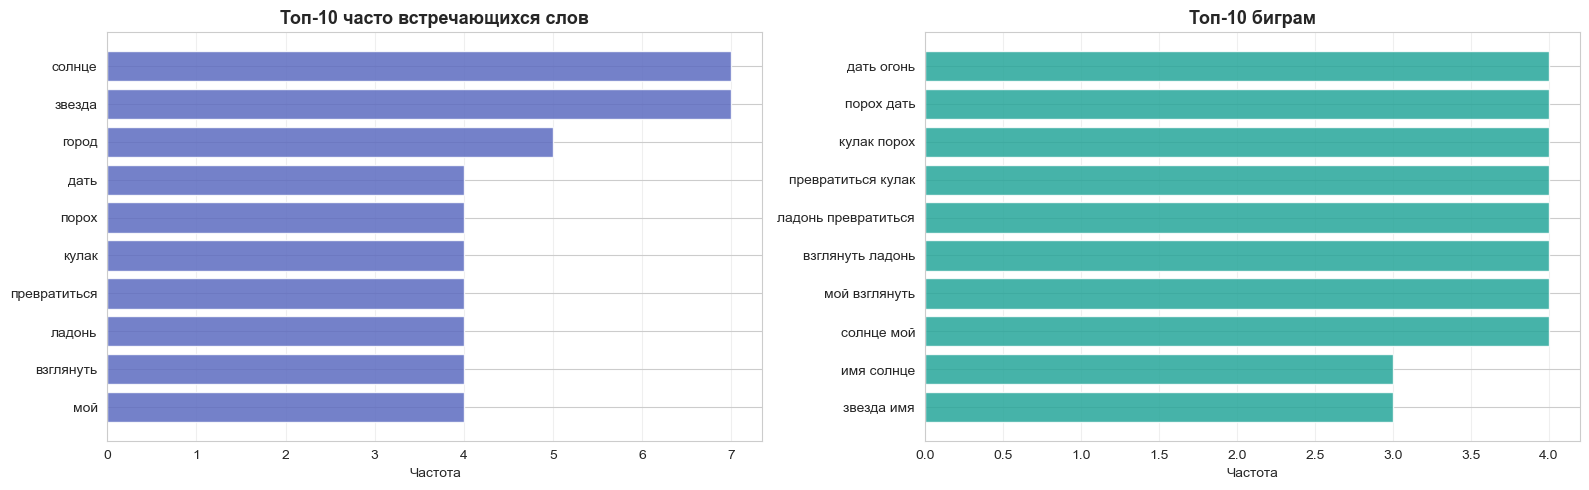

In [27]:
bigrams = list(ngrams(all_tokens, 2))
bigram_freq = Counter(bigrams)
top10_bigrams = bigram_freq.most_common(10)

df_bigrams = pd.DataFrame(
    [(' '.join(bg), freq) for bg, freq in top10_bigrams],
    columns=['Биграм', 'Частота']
)
print('Топ-10 биграм:')
print(df_bigrams.to_string(index=False))

# Визуализация: частые слова и биграммы
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

words_df = pd.DataFrame(top10_words, columns=['Слово', 'Частота']).sort_values('Частота')
axes[0].barh(words_df['Слово'], words_df['Частота'], color='#5C6BC0', alpha=0.85)
axes[0].set_title('Топ-10 часто встречающихся слов', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Частота')
axes[0].grid(axis='x', alpha=0.3)

bg_df = df_bigrams.sort_values('Частота')
axes[1].barh(bg_df['Биграм'], bg_df['Частота'], color='#26A69A', alpha=0.85)
axes[1].set_title('Топ-10 биграм', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Частота')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()


Вывод: Топ-10 биграм полностью состоят из цепочки рефрена «Кукушки»:
«солнце мой» → «мой взглянуть» → «взглянуть ладонь» → ... → «дать огонь» (частота 4).
Это прямое следствие того, что припев повторяется трижды — биграммный анализ
автоматически выявил повторяющуюся структуру текста. Биграмы «звезда имя» и
«имя солнце» (частота 3) отражают название и лейтмотив третьей песни.

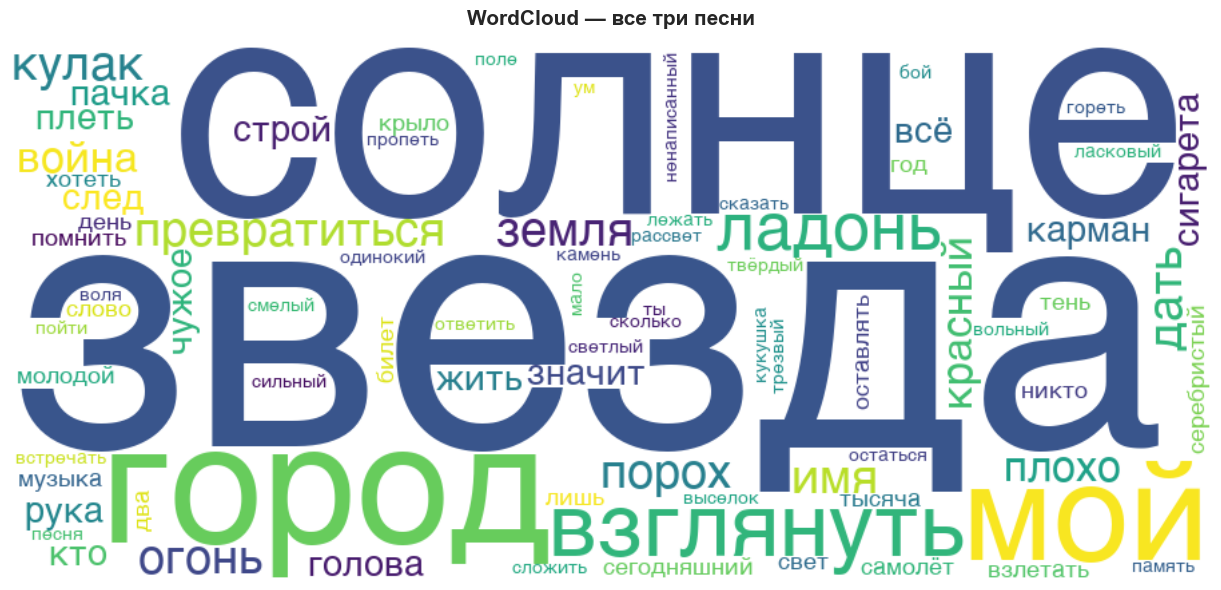

In [30]:
word_freq_dict = dict(word_freq)

try:
    import os
    font_candidates = [
        '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
        '/System/Library/Fonts/Helvetica.ttc',
    ]
    font_path = next((f for f in font_candidates if os.path.exists(f)), None)
    
    wc = WordCloud(
        width=900, height=400,
        background_color='white',
        colormap='viridis',
        max_words=80,
        font_path=font_path
    ).generate_from_frequencies(word_freq_dict)
    
    plt.figure(figsize=(14, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('WordCloud — все три песни', fontsize=15, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
    plt.show()
    
except Exception as e:
    print(f'{e}')

Вывод: WordCloud визуально подтверждает частотный анализ: доминируют «солнце»,
«звезда», «город» — слова, присутствующие в нескольких песнях. Заметно тематическое
расслоение: левая часть облака — слова («воля», «след», «пойти»,
«чужое»), правая — какие то конкретные образы («сигарета», «карман», «билет»,
«самолёт»). Центр занимаю глаголы («жить», «значит», «превратиться»).

Слов для t-SNE: 149


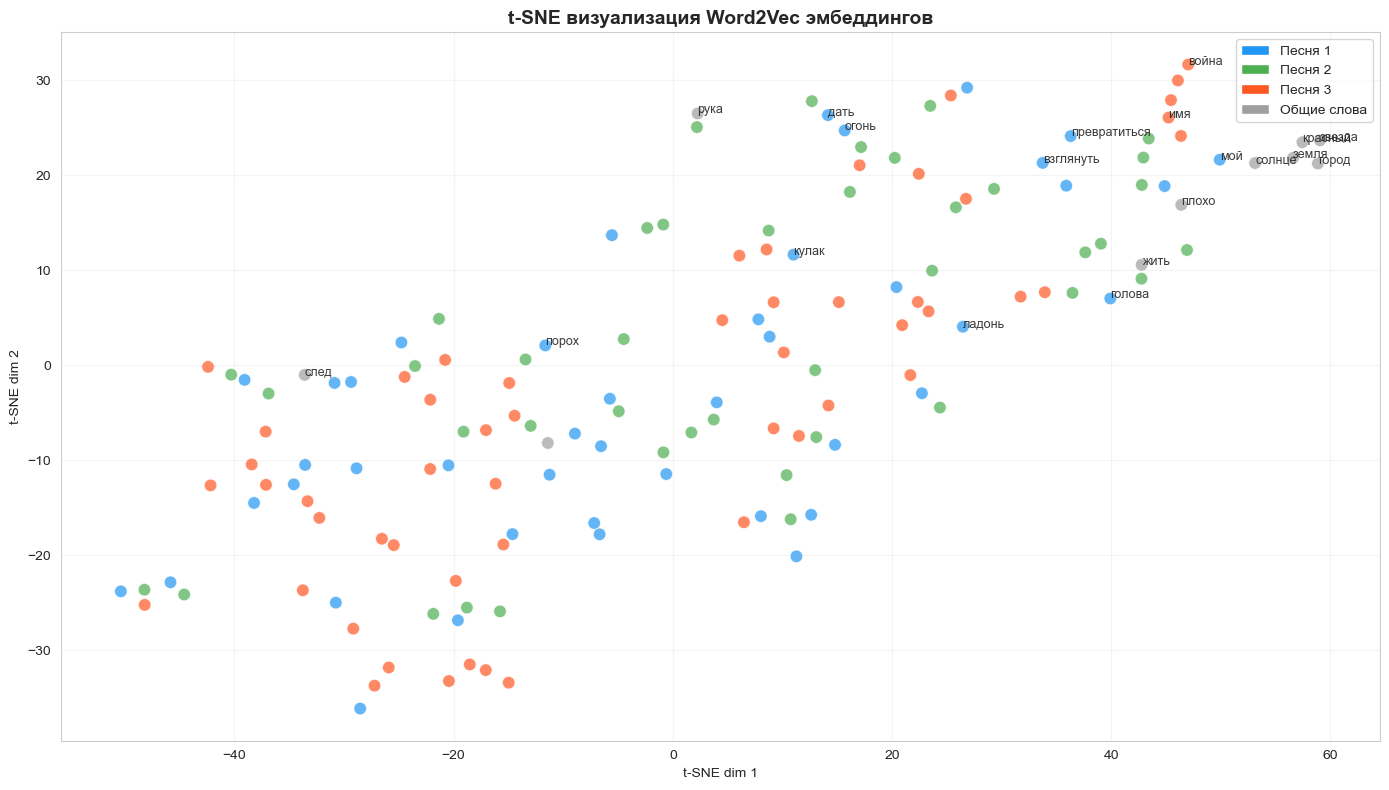

In [33]:
vocab_words = list(w2v_model.wv.key_to_index.keys())
word_vectors = np.array([w2v_model.wv[w] for w in vocab_words])

print(f'Слов для t-SNE: {len(vocab_words)}')

if len(vocab_words) >= 4:
    # t-SNE: снижаем размерность 50D → 2D
    perplexity = min(5, len(vocab_words) - 1)
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42,
    )
    vectors_2d = tsne.fit_transform(word_vectors)
    
    point_colors = []
    color_map = {'Песня 1': '#2196F3', 'Песня 2': '#4CAF50', 'Песня 3': '#FF5722', 'общее': '#9E9E9E'}
    
    for word in vocab_words:
        in_songs = [name for name, tokens in processed_songs.items() if word in tokens]
        if len(in_songs) == 1:
            point_colors.append(color_map[in_songs[0]])
        else:
            point_colors.append(color_map['общее'])
    
    plt.figure(figsize=(14, 8))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1],
                c=point_colors, alpha=0.7, s=80, edgecolors='white', linewidth=0.5)
    
    top_words_set = {w for w, _ in word_freq.most_common(20)}
    for i, word in enumerate(vocab_words):
        if word in top_words_set:
            plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]),
                        fontsize=9, alpha=0.9)
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2196F3', label='Песня 1'),
        Patch(facecolor='#4CAF50', label='Песня 2'),
        Patch(facecolor='#FF5722', label='Песня 3'),
        Patch(facecolor='#9E9E9E', label='Общие слова')
    ]
    plt.legend(handles=legend_elements, loc='best', fontsize=10)
    plt.title('t-SNE визуализация Word2Vec эмбеддингов', fontsize=14, fontweight='bold')
    plt.xlabel('t-SNE dim 1')
    plt.ylabel('t-SNE dim 2')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig('tsne.png', dpi=150, bbox_inches='tight')
    plt.show()


Вывод: t-SNE на 149 словах не образует чётких изолированных кластеров по песням —
точки трёх цветов перемешаны по всему пространству. Это объясняется единым авторским
стилем: все три песни написаны одним автором. Тем не менее,
прослеживается локальная группировка: «война», «имя», «город» (оранжевые) тяготеют
к правому верхнему углу, тогда как «порох», «след» смещены влево. Серые точки
(общие слова: «звезда», «солнце») закономерно расположены между кластерами.
Word2Vec на малом корпусе даёт нестабильные эмбеддинги — для чёткой кластеризации
необходим корпус больше, чем имеется.

---
# Часть 4 — Классификация тональности с помощью BERT

Используем предобученную модель `bert-base-uncased` с Hugging Face для бинарной классификации отзывов IMDB (positive / negative).


In [1]:
import sys
print(sys.executable)  # покажет какой Python используется
!{sys.executable} -m pip install torch torchvision torchaudio

/opt/miniconda3/envs/nlp_env/bin/python


In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score
import time

if torch.backends.mps.is_available():
    device = torch.device('mps')      # Apple Silicon GPU 
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'{device}')

mps


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('IMDB Dataset.csv')

# Приводим метки к числам
df['label'] = (df['sentiment'] == 'positive').astype(int)

print(f'Всего записей: {len(df)}')
print(df['sentiment'].value_counts())

TRAIN_SIZE = 2000
TEST_SIZE = 500

df_sample = df.sample(TRAIN_SIZE + TEST_SIZE, random_state=42).reset_index(drop=True)

train_df = df_sample[:TRAIN_SIZE]
test_df  = df_sample[TRAIN_SIZE:]

train_texts = train_df['review'].tolist()
train_labels = train_df['label'].tolist()
test_texts  = test_df['review'].tolist()
test_labels = test_df['label'].tolist()

print(f'Train: {len(train_texts)}')
print(f'Test:  {len(test_texts)}')
print(f'Распределение меток в train: pos={sum(train_labels)}, neg={len(train_labels)-sum(train_labels)}')

Всего записей: 50000
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
Train: 2000
Test:  500
Распределение меток в train: pos=976, neg=1024


In [3]:
import re 

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)         # убираем HTML теги
    text = re.sub(r'\s+', ' ', text).strip()   # нормализуем пробелы
    return text

train_texts_clean = [clean_text(t) for t in train_texts]
test_texts_clean  = [clean_text(t) for t in test_texts]

print(f'Пример:')
print(train_texts_clean[0][:200])

Пример:
I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ev


In [4]:
MAX_LEN = 256  # максимальная длина токенов (512 максимум у BERT)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_batch(texts, tokenizer, max_len=MAX_LEN):
    """
    Токенизация с паддингом и обрезкой.
    """
    encoding = tokenizer(
        texts,
        padding='max_length',      # паддинг до max_len
        truncation=True,           # обрезка длинных текстов
        max_length=max_len,
        return_tensors='pt'        # возвращаем PyTorch тензоры
    )
    return encoding

train_encodings = tokenize_batch(train_texts_clean, tokenizer)
test_encodings  = tokenize_batch(test_texts_clean, tokenizer)

print(f'input_ids shape (train): {train_encodings["input_ids"].shape}')
print(f'attention_mask shape:    {train_encodings["attention_mask"].shape}')

/opt/miniconda3/envs/nlp_env/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

input_ids shape (train): torch.Size([2000, 256])
attention_mask shape:    torch.Size([2000, 256])


In [6]:
class IMDBDataset(Dataset):
    def __init__(self, encodings, labels):
        self.input_ids      = encodings['input_ids']
        self.attention_mask = encodings['attention_mask']
        self.labels         = torch.tensor(labels, dtype=torch.long)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return {
            'input_ids':      self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels':         self.labels[idx]
        }

train_dataset = IMDBDataset(train_encodings, list(train_labels))
test_dataset  = IMDBDataset(test_encodings,  list(test_labels))

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 125
Test batches:  32


Вывод: Dataset корректно инициализирован — 125 батчей для обучения
и 32 для теста при batch_size=16. Все три обязательных поля BERT
(input_ids, attention_mask, labels) передаются в каждом батче.

In [7]:
# BertForSequenceClassification = BERT + Linear(768, num_labels)
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2   # бинарная классификация: 0=negative, 1=positive
)
model = model.to(device)

# Оптимизатор с дифференцированным learning rate
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Всего параметров: {total_params:,}')
print(f'Обучаемых:        {trainable_params:,}')

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Всего параметров: 109,483,778
Обучаемых:        109,483,778


In [8]:
#Fine-tuning BERT
EPOCHS = 3
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    t_start = time.time()
    
    for batch_idx, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        total_loss += loss.item()
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        if (batch_idx + 1) % 20 == 0:
            print(f'  Эпоха {epoch+1}/{EPOCHS} | Батч {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}')
    
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    elapsed = time.time() - t_start
    print(f'\Эпоха {epoch+1}| Avg Loss: {avg_loss:.4f} | Время: {elapsed:.1f}с\n')

  Эпоха 1/3 | Батч 20/125 | Loss: 0.6750
  Эпоха 1/3 | Батч 40/125 | Loss: 0.3781
  Эпоха 1/3 | Батч 60/125 | Loss: 0.4889
  Эпоха 1/3 | Батч 80/125 | Loss: 0.3430
  Эпоха 1/3 | Батч 100/125 | Loss: 0.3911
  Эпоха 1/3 | Батч 120/125 | Loss: 0.4641
\Эпоха 1| Avg Loss: 0.4583 | Время: 137.4с

  Эпоха 2/3 | Батч 20/125 | Loss: 0.0869
  Эпоха 2/3 | Батч 40/125 | Loss: 0.2161
  Эпоха 2/3 | Батч 60/125 | Loss: 0.2577
  Эпоха 2/3 | Батч 80/125 | Loss: 0.0618
  Эпоха 2/3 | Батч 100/125 | Loss: 0.0323
  Эпоха 2/3 | Батч 120/125 | Loss: 0.3458
\Эпоха 2| Avg Loss: 0.2136 | Время: 127.2с

  Эпоха 3/3 | Батч 20/125 | Loss: 0.0229
  Эпоха 3/3 | Батч 40/125 | Loss: 0.1285
  Эпоха 3/3 | Батч 60/125 | Loss: 0.3948
  Эпоха 3/3 | Батч 80/125 | Loss: 0.0147
  Эпоха 3/3 | Батч 100/125 | Loss: 0.1244
  Эпоха 3/3 | Батч 120/125 | Loss: 0.0031
\Эпоха 3| Avg Loss: 0.1179 | Время: 131.1с



Вывод: Динамика обучения стабильна — loss снижается с 0.458 → 0.214 → 0.118
по эпохам. В третьей эпохе loss достигает 0.0031 на отдельных батчах,
что говорит о хорошей сходимости. Время на эпоху ~130 сек на Apple M3 18GB RAM.

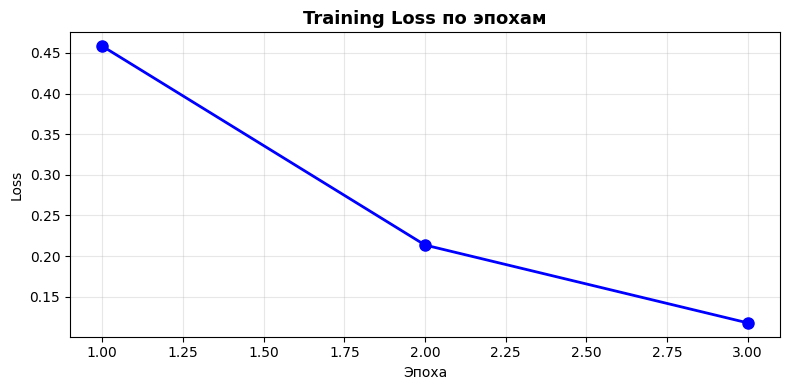

In [11]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), train_losses, 'bo-', linewidth=2, markersize=8)
plt.title('Training Loss по эпохам', fontsize=13, fontweight='bold')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('bert_loss.png', dpi=150)
plt.show()

Вывод: Кривая обучения имеет убывающую форму без скачков
и плато. Снижение в 3.6 раза за 3 эпохи подтверждает эффективность fine-tuning BERT.

In [15]:
model.eval()
all_preds = []
all_true  = []
inference_times = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels']
        
        t0 = time.time()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        inference_times.append((time.time() - t0) / len(labels))
        
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(labels.numpy())

# Метрики
accuracy = accuracy_score(all_true, all_preds)
f1 = f1_score(all_true, all_preds, average='weighted')
avg_inference = np.mean(inference_times)

print(f'Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'F1-score:  {f1:.4f}')
print(f'Время инференса на 1 отзыв: {avg_inference*1000:.2f} мс')
print(classification_report(all_true, all_preds, target_names=['Negative', 'Positive']))

Accuracy:  0.8720 (87.20%)
F1-score:  0.8726
Время инференса на 1 отзыв: 1.46 мс
              precision    recall  f1-score   support

    Negative       0.80      0.93      0.86       215
    Positive       0.94      0.83      0.88       285

    accuracy                           0.87       500
   macro avg       0.87      0.88      0.87       500
weighted avg       0.88      0.87      0.87       500



Вывод: Accuracy 87.2% и F1=0.87 — хороший результат для 2000 примеров.
Positive класс имеет высокую precision (0.94) — модель редко ошибочно
классифицирует негативные отзывы как позитивные. Negative recall (0.93)
означает что 93% негативных отзывов найдены корректно.
Время инференса 1.46 мс/отзыв.

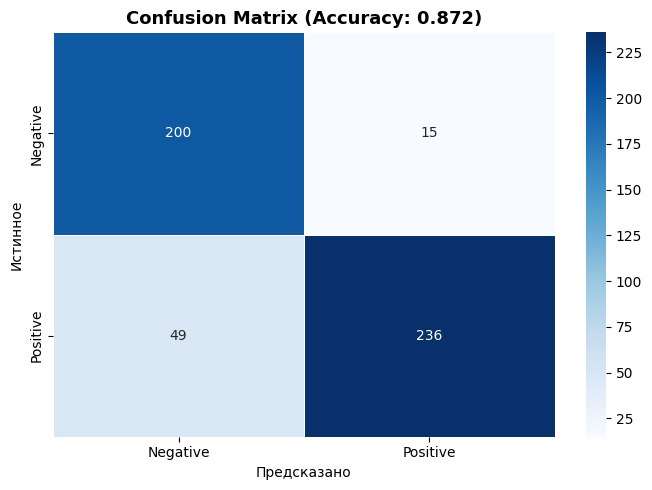

In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    linewidths=0.5
)
plt.title(f'Confusion Matrix (Accuracy: {accuracy:.3f})', fontsize=13, fontweight='bold')
plt.xlabel('Предсказано')
plt.ylabel('Истинное')
plt.tight_layout()
plt.savefig('bert_confusion_matrix.png', dpi=150)
plt.show()

In [17]:
def predict_sentiment(text, model, tokenizer, device):
    """Предсказание тональности одного текста"""
    text = clean_text(text)
    encoding = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='pt'
    )
    
    model.eval()
    with torch.no_grad():
        t0 = time.time()
        output = model(
            input_ids=encoding['input_ids'].to(device),
            attention_mask=encoding['attention_mask'].to(device)
        )
        inf_time = time.time() - t0
    
    probs = torch.softmax(output.logits, dim=1).cpu().numpy()[0]
    pred  = np.argmax(probs)
    label = 'POSITIVE' if pred == 1 else 'NEGATIVE'
    
    return label, probs[1], probs[0], inf_time

test_examples = [
    "This movie was absolutely fantastic! Great acting and brilliant story.",
    "Terrible film. Boring, predictable and a complete waste of time.",
    "It was okay, not great but not terrible either. Average experience.",
    "One of the best movies I have ever seen! Highly recommend!",
    "I fell asleep halfway through. Nothing interesting happens."
]

print('Ручная проверка на примерах:')
for text in test_examples:
    label, pos_prob, neg_prob, inf_t = predict_sentiment(text, model, tokenizer, device)
    print(f'Текст: "{text[:60]}"')
    print(f'  → {label} | P(pos)={pos_prob:.3f} | P(neg)={neg_prob:.3f} | {inf_t*1000:.1f}мс')
    print()

Ручная проверка на примерах:
Текст: "This movie was absolutely fantastic! Great acting and brilli"
  → POSITIVE | P(pos)=0.997 | P(neg)=0.003 | 1470.2мс

Текст: "Terrible film. Boring, predictable and a complete waste of t"
  → NEGATIVE | P(pos)=0.003 | P(neg)=0.997 | 20.9мс

Текст: "It was okay, not great but not terrible either. Average expe"
  → NEGATIVE | P(pos)=0.015 | P(neg)=0.985 | 18.3мс

Текст: "One of the best movies I have ever seen! Highly recommend!"
  → POSITIVE | P(pos)=0.997 | P(neg)=0.003 | 18.0мс

Текст: "I fell asleep halfway through. Nothing interesting happens."
  → NEGATIVE | P(pos)=0.005 | P(neg)=0.995 | 17.8мс



Модель уверенно классифицирует явно позитивные и негативные отзывы
с вероятностью 0.997 — практически без сомнений. Интересный случай:
нейтральный отзыв ("okay, not great but not terrible") отнесён к негативам
с P=0.985 — модель интерпретирует отсутствие восторга как негатив